In [2]:
import pandas as pd
import numpy as np

PATH = "/kaggle/input/datasets/avtnshm/ssl-master-dataset/ssl_master_dataset (2).csv"

df = pd.read_csv(PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (130, 11)


,Experiment,Dataset,Architecture,Seed,Method,Tau,Jacobian,Aug_Sensitivity,Noise_Sensitivity,Accuracy,Train_Time_Min
0,Core,CIFAR10,ResNet18,0,BYOL,NaN,64.739576,13.125267,13.745380,0.6474,NaN
1,Core,CIFAR10,ResNet18,0,SimCLR,NaN,89.379337,15.684288,19.091714,0.6905,NaN
2,Core,CIFAR10,ResNet18,0,SimCLR+Jac,NaN,66.768893,15.795745,15.709850,0.6760,NaN
3,Core,CIFAR10,ResNet18,1,BYOL,NaN,63.238374,12.338819,12.546963,0.6530,NaN
4,Core,CIFAR10,ResNet18,1,SimCLR,NaN,87.060588,15.589313,18.490107,0.6975,NaN


### Experimental Data Tables

In [3]:
print("\nExperiments:", df["Experiment"].unique())
print("\nDatasets:", df["Dataset"].unique())
print("\nMethods:", df["Method"].unique())


Experiments: ['Core' 'Tau' 'Extension' 'Transfer_100E' 'Transfer_20E' 'Probe_CIFAR100']

Datasets: ['CIFAR10' 'STL10' 'CIFAR100']

Methods: ['BYOL' 'SimCLR' 'SimCLR+Jac']


In [4]:
df_core = df[df["Experiment"] == "Core"]

core_stats = df_core.groupby("Method").agg({
    "Jacobian": ["mean","std"],
    "Aug_Sensitivity": ["mean","std"],
    "Noise_Sensitivity": ["mean","std"],
    "Accuracy": ["mean","std"]
}).round(4)

display(core_stats)

Jacobian         Aug_Sensitivity         Noise_Sensitivity          \
               mean     std            mean     std              mean     std   
Method                                                                          
BYOL        62.3177  3.7565         12.7610  0.5148           13.2679  0.9387   
SimCLR      87.5213  1.7925         15.6302  0.3186           18.6500  0.7093   
SimCLR+Jac  65.9729  0.9898         15.5393  0.6224           16.0637  0.3935   

           Accuracy          
               mean     std  
Method                       
BYOL         0.6533  0.0053  
SimCLR       0.6947  0.0052  
SimCLR+Jac   0.6751  0.0034

In [5]:
df_tau = df[df["Experiment"] == "Tau"]

tau_stats = df_tau.groupby("Tau").agg({
    "Jacobian": ["mean","std"],
    "Noise_Sensitivity": ["mean","std"]
}).round(4)

display(tau_stats)

Jacobian         Noise_Sensitivity        
         mean     std              mean     std
Tau                                            
0.1  104.8962  1.3415           19.6332  0.6250
0.5   88.7575  1.4338           19.0864  0.5394
1.0   77.6758  1.7367           18.1770  0.9179

In [6]:
df_t100 = df[df["Experiment"] == "Transfer_100E"]
df_t20  = df[df["Experiment"] == "Transfer_20E"]

print("Transfer 100E")
display(df_t100.groupby("Method")["Accuracy"].agg(["mean","std"]).round(4))

print("\nTransfer 20E")
display(df_t20.groupby("Method")["Accuracy"].agg(["mean","std"]).round(4))

Transfer 100E


,mean,std
Method,,
BYOL,0.6454,0.0043
SimCLR,0.6829,0.0024
SimCLR+Jac,0.6821,0.0020



Transfer 20E


,mean,std
Method,,
BYOL,0.4967,0.0035
SimCLR,0.5993,0.0067
SimCLR+Jac,0.6013,0.0047


In [7]:
df_probe = df[df["Experiment"] == "Probe_CIFAR100"]

display(df_probe.groupby("Method")["Accuracy"].agg(["mean","std"]).round(4))

,mean,std
Method,,
SimCLR,0.3941,0.0029
SimCLR+Jac,0.3974,0.0041


### Plots

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120
})

sns.set_style("whitegrid")

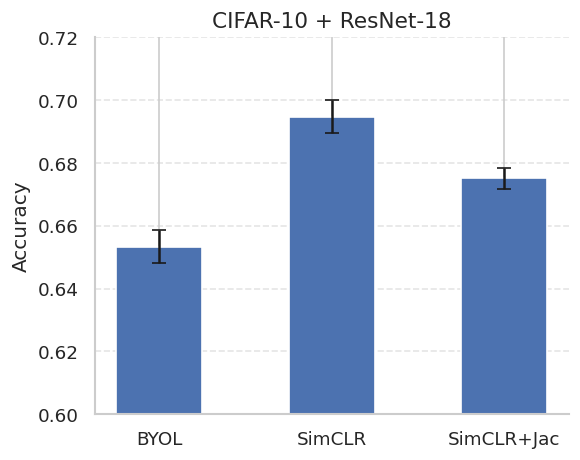

In [25]:
import numpy as np

df_core = df[df["Experiment"] == "Core"]

stats = df_core.groupby("Method")["Accuracy"].agg(["mean","std"]).reset_index()

plt.figure(figsize=(5,4))

bars = plt.bar(
    stats["Method"],
    stats["mean"],
    yerr=stats["std"],
    capsize=4,
    width=0.5   # 👈 reduced width (key fix)
)

plt.ylabel("Accuracy")
plt.title("CIFAR-10 + ResNet-18")

plt.ylim(0.60, 0.72)  # tighter range = more readable

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=0)

sns.despine()
plt.tight_layout()
plt.show()

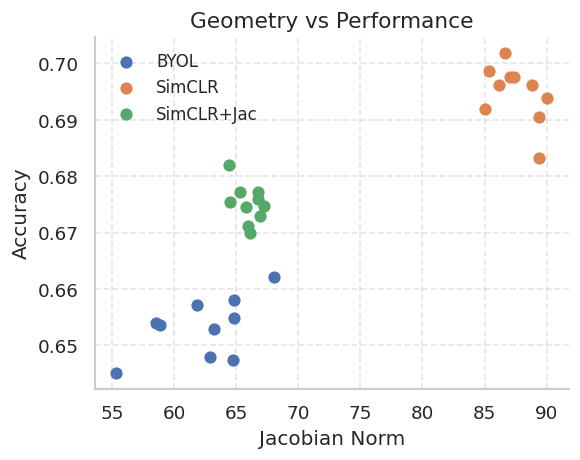

In [28]:
plt.figure(figsize=(5,4))

for method in df_core["Method"].unique():
    d = df_core[df_core["Method"] == method]
    plt.scatter(
        d["Jacobian"],
        d["Accuracy"],
        label=method,
        s=40  # clean marker size
    )

plt.xlabel("Jacobian Norm")
plt.ylabel("Accuracy")
plt.title("Geometry vs Performance")

plt.legend(frameon=False)

plt.grid(True, linestyle="--", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()

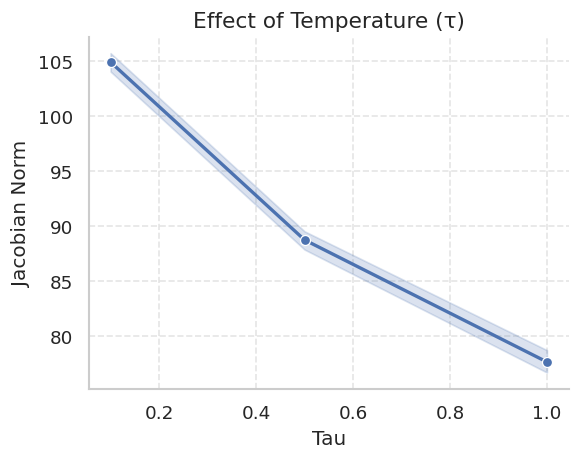

In [27]:
df_tau = df[df["Experiment"] == "Tau"]

plt.figure(figsize=(5,4))

sns.lineplot(
    data=df_tau,
    x="Tau",
    y="Jacobian",
    marker="o",
    linewidth=2
)

plt.title("Effect of Temperature (τ)")
plt.ylabel("Jacobian Norm")

plt.grid(True, linestyle="--", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()

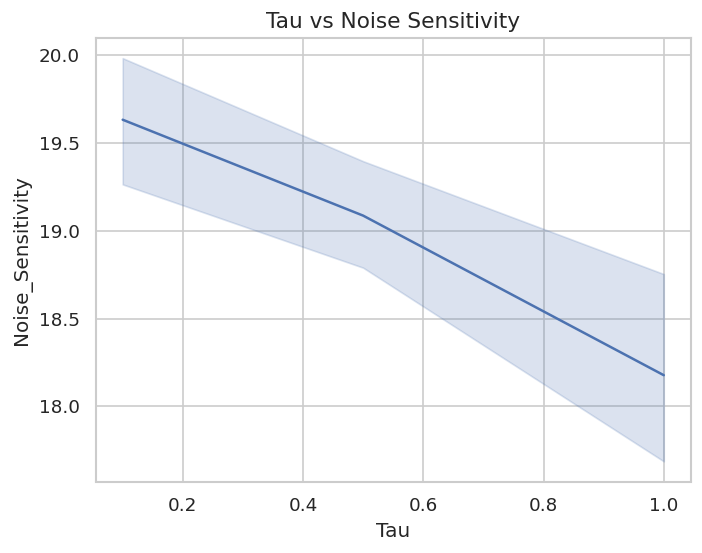

In [20]:
plt.figure()
sns.lineplot(data=df_tau, x="Tau", y="Noise_Sensitivity", estimator="mean")
plt.title("Tau vs Noise Sensitivity")
plt.show()

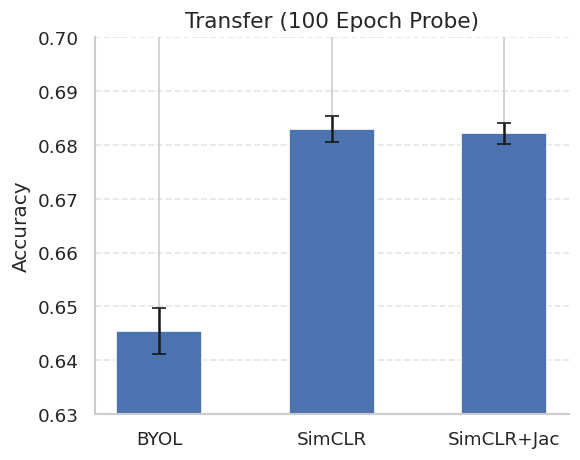

In [26]:
df_t100 = df[df["Experiment"] == "Transfer_100E"]

stats = df_t100.groupby("Method")["Accuracy"].agg(["mean","std"]).reset_index()

plt.figure(figsize=(5,4))

plt.bar(
    stats["Method"],
    stats["mean"],
    yerr=stats["std"],
    capsize=4,
    width=0.5
)

plt.ylabel("Accuracy")
plt.title("Transfer (100 Epoch Probe)")

plt.ylim(0.63, 0.70)

plt.grid(axis="y", linestyle="--", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()

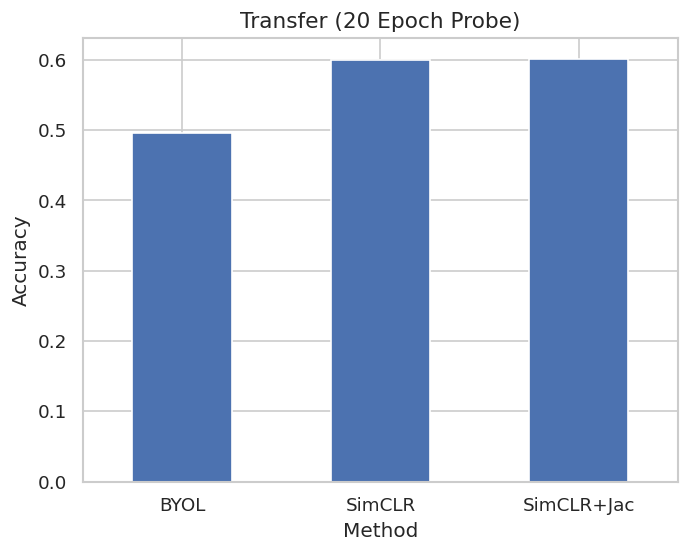

In [22]:
plt.figure()
df_t20.groupby("Method")["Accuracy"].mean().plot(kind="bar")
plt.title("Transfer (20 Epoch Probe)")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

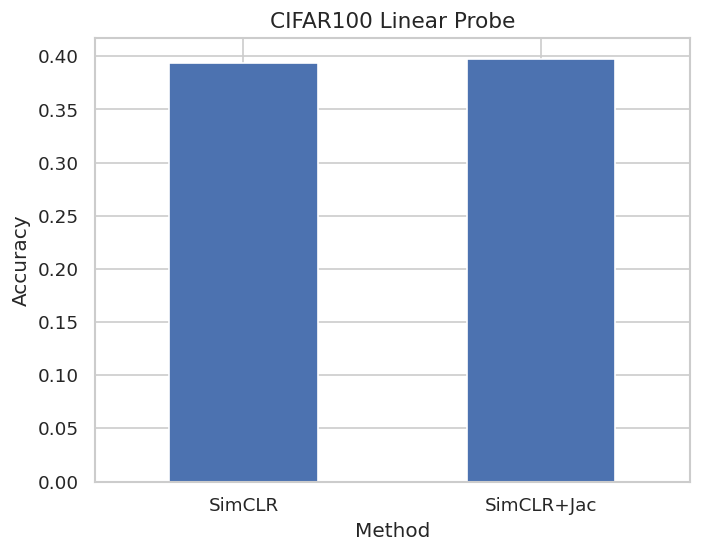

In [23]:
plt.figure()
df_probe.groupby("Method")["Accuracy"].mean().plot(kind="bar")
plt.title("CIFAR100 Linear Probe")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

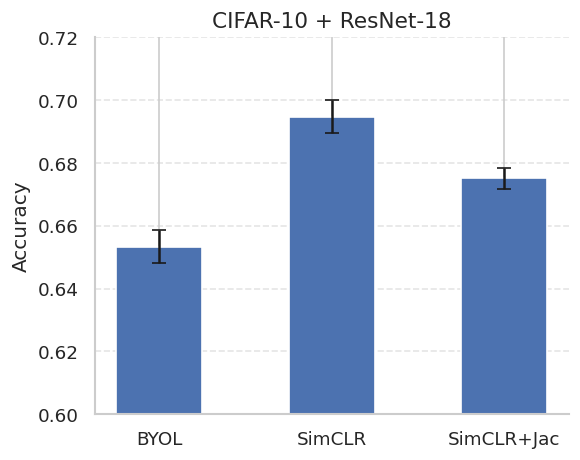

In [24]:
import numpy as np

df_core = df[df["Experiment"] == "Core"]

stats = df_core.groupby("Method")["Accuracy"].agg(["mean","std"]).reset_index()

plt.figure(figsize=(5,4))

bars = plt.bar(
    stats["Method"],
    stats["mean"],
    yerr=stats["std"],
    capsize=4,
    width=0.5   # 👈 reduced width (key fix)
)

plt.ylabel("Accuracy")
plt.title("CIFAR-10 + ResNet-18")

plt.ylim(0.60, 0.72)  # tighter range = more readable

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=0)

sns.despine()
plt.tight_layout()
plt.show()